#📌 Extracão

# 1. Extração de Dados

Nesta etapa realizamos a extração dos dados utilizados na análise.  
O dataset está armazenado em um arquivo JSON chamado **TelecomX_Data.json**, localizado na mesma pasta deste notebook.

Utilizaremos a biblioteca **Pandas** para carregar os dados e convertê-los em um DataFrame, facilitando as etapas posteriores de transformação e análise.

In [3]:
import pandas as pd

arquivo_json = "TelecomX_Data.json"
dados = pd.read_json(arquivo_json)
dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

# 2. Transformação dos Dados

Após a extração dos dados, iniciamos a etapa de transformação.
Nesta fase os dados são preparados para análise, garantindo que estejam
organizados, consistentes e sem inconsistências.

As principais atividades desta etapa incluem:

- Normalização da estrutura do JSON
- Verificação de valores ausentes
- Ajuste de tipos de dados
- Padronização das colunas

Essas transformações são necessárias para garantir a qualidade
da análise exploratória realizada nas próximas etapas.

In [4]:
# Criar cópia do dataset
dados_transformados = dados.copy()

# Expandir colunas com dicionários
customer_df = pd.json_normalize(dados_transformados['customer']).add_prefix("customer_")
phone_df = pd.json_normalize(dados_transformados['phone']).add_prefix("phone_")
internet_df = pd.json_normalize(dados_transformados['internet']).add_prefix("internet_")
account_df = pd.json_normalize(dados_transformados['account']).add_prefix("account_")

# Remover colunas originais
dados_transformados = dados_transformados.drop(columns=['customer','phone','internet','account'])

# Juntar dados
dados_transformados = pd.concat(
    [dados_transformados, customer_df, phone_df, internet_df, account_df],
    axis=1
)

# Converter valores numéricos se a coluna existir
if "account_Charges_Total" in dados_transformados.columns:
    dados_transformados["account_Charges_Total"] = pd.to_numeric(
        dados_transformados["account_Charges_Total"],
        errors="coerce"
    )

# Ajustar coluna SeniorCitizen
dados_transformados["customer_SeniorCitizen"] = dados_transformados["customer_SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

#📊 Carga e análise

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
for col in df.columns:
    print(col)

Dimensão do dataset: (7267, 21)

Distribuição de Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


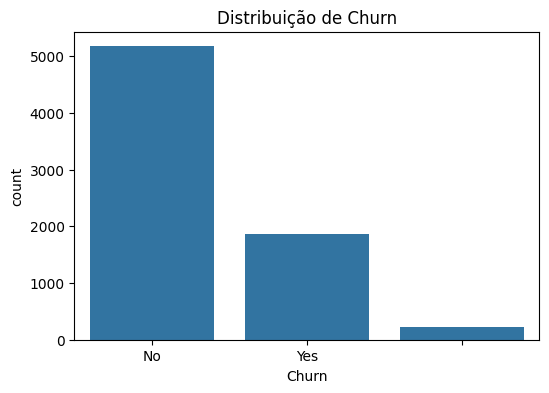

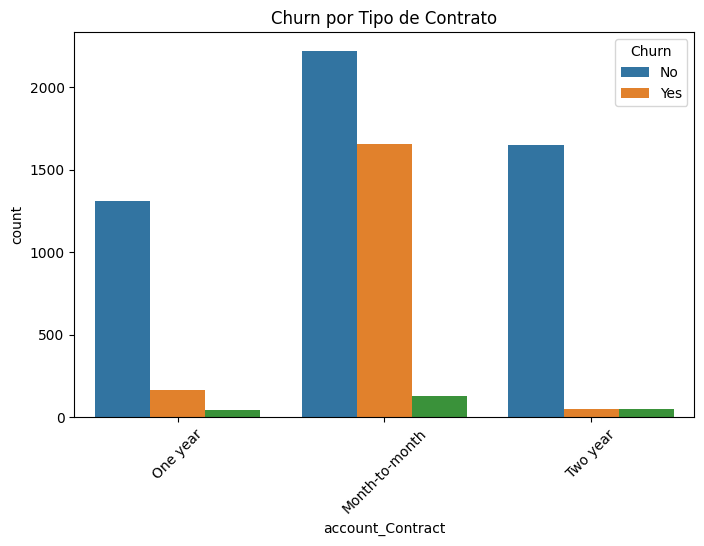

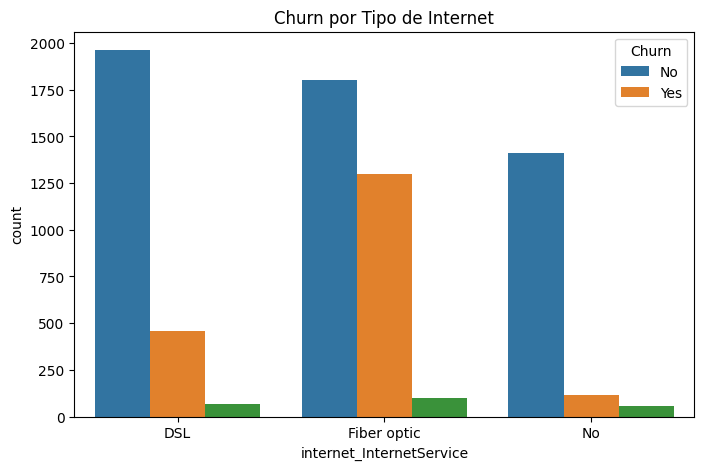

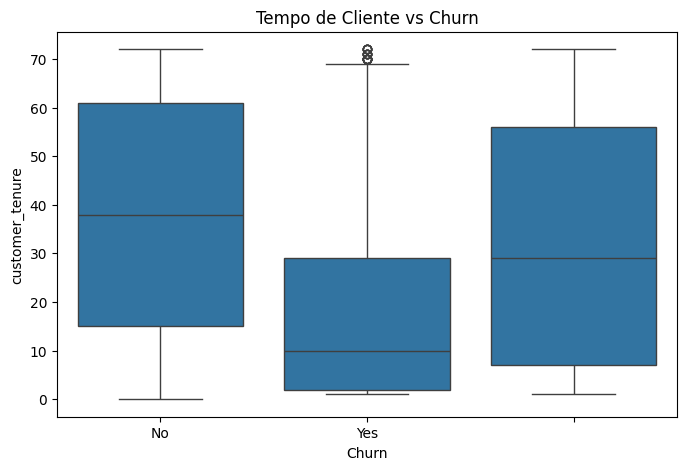

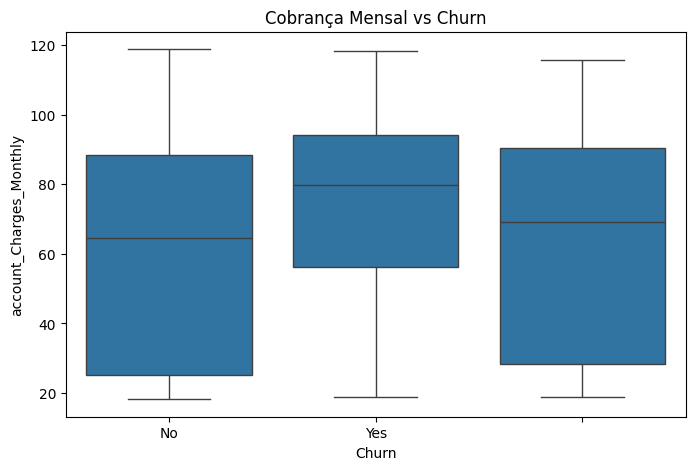

In [9]:

# Criar dataset para análise
df = dados_transformados.copy()

# Padronizar nomes das colunas
df.columns = df.columns.str.replace(".", "_", regex=False)

# Converter coluna de cobrança total para número
df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

# Informações gerais do dataset
print("Dimensão do dataset:", df.shape)
print("\nDistribuição de Churn:")
print(df["Churn"].value_counts())

# -------------------------------
# Gráfico 1 - Distribuição de churn
# -------------------------------

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribuição de Churn")
plt.show()

# -------------------------------
# Gráfico 2 - Churn por tipo de contrato
# -------------------------------

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="account_Contract", hue="Churn")
plt.title("Churn por Tipo de Contrato")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# Gráfico 3 - Churn por tipo de internet
# -------------------------------

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="internet_InternetService", hue="Churn")
plt.title("Churn por Tipo de Internet")
plt.show()

# -------------------------------
# Gráfico 4 - Tempo de cliente vs churn
# -------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="customer_tenure")
plt.title("Tempo de Cliente vs Churn")
plt.show()

# -------------------------------
# Gráfico 5 - Valor mensal vs churn
# -------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="account_Charges_Monthly")
plt.title("Cobrança Mensal vs Churn")
plt.show()

#📄Relatorio Final

# Relatório Final — Análise de Evasão de Clientes (Churn)

## 1. Introdução

A evasão de clientes (churn) é um dos principais desafios enfrentados por empresas de telecomunicações, pois impacta diretamente a receita e a sustentabilidade do negócio. A Telecom X identificou um aumento na taxa de cancelamento de serviços e iniciou um projeto de análise de dados para compreender melhor esse comportamento.

O objetivo deste estudo foi realizar o processo de **ETL (Extração, Transformação e Carga)** dos dados disponibilizados pela empresa e conduzir uma **análise exploratória (EDA)** para identificar possíveis padrões associados ao churn.

Os dados utilizados foram disponibilizados em formato **JSON**, contendo informações sobre perfil dos clientes, serviços contratados, características da conta e status de cancelamento.

---

## 2. Processo de ETL

### Extração

Na etapa de extração, os dados foram carregados a partir de um arquivo **JSON** disponibilizado pela empresa. Utilizando a biblioteca **Pandas**, os dados foram importados para um DataFrame para permitir manipulação e análise.

### Transformação

Os dados apresentavam algumas estruturas aninhadas (dicionários dentro de colunas), como:

- `customer`
- `phone`
- `internet`
- `account`

Essas estruturas foram **normalizadas**, expandindo os dicionários em colunas individuais para facilitar a análise.

Também foram realizadas as seguintes transformações:

- Expansão das colunas aninhadas em variáveis separadas
- Padronização dos nomes das colunas
- Conversão de variáveis numéricas (como valores de cobrança)
- Ajuste de variáveis categóricas para melhorar a interpretação
- Verificação da estrutura final dos dados

Após essas transformações, os dados ficaram organizados em um formato tabular adequado para análise.

### Carga para análise

Com os dados tratados, foi criado um DataFrame final contendo todas as variáveis relevantes, permitindo a realização da análise exploratória.

---

## 3. Análise Exploratória de Dados (EDA)

Durante a análise exploratória, foram investigadas algumas relações entre características dos clientes e a ocorrência de churn.

Entre os principais pontos observados:

- A distribuição geral dos clientes mostrou uma parcela significativa de cancelamentos.
- Clientes com **contratos mensais (Month-to-month)** apresentaram maior propensão ao churn.
- O tipo de serviço de internet também apresentou relação com o cancelamento, indicando diferenças no comportamento entre tipos de conexão.
- Clientes com **menor tempo de permanência (tenure)** tendem a cancelar mais rapidamente.
- O valor da mensalidade pode influenciar o churn, indicando que clientes com custos mais elevados podem apresentar maior sensibilidade ao cancelamento.

Essas análises ajudam a identificar padrões importantes no comportamento dos clientes.

---

## 4. Conclusão

A análise realizada permitiu compreender melhor alguns fatores associados à evasão de clientes da Telecom X.

Os resultados indicam que características contratuais, tempo de relacionamento com a empresa e aspectos relacionados ao serviço contratado podem influenciar a decisão de cancelamento.

Essas informações são importantes para apoiar estratégias de retenção de clientes e orientar ações da equipe de Data Science.

---

## 5. Recomendações

Com base nos resultados obtidos, algumas possíveis ações incluem:

- Incentivar contratos de maior duração, reduzindo a dependência de contratos mensais.
- Criar estratégias de retenção para clientes nos primeiros meses de contrato.
- Avaliar a percepção de valor dos serviços oferecidos, principalmente em planos com mensalidades mais elevadas.
- Investigar mais profundamente a experiência de clientes com determinados serviços de internet.

Essas iniciativas podem contribuir para reduzir a taxa de churn e melhorar o relacionamento da empresa com seus clientes.

---

## 6. Próximos Passos

Como continuação deste projeto, os dados tratados podem ser utilizados para o desenvolvimento de **modelos preditivos de churn**, permitindo identificar clientes com maior probabilidade de cancelamento e possibilitando ações preventivas.